# JUMP-CP metadata exploration

A first look at the JUMP Cell Painting dataset (cpg0016) from its public metadata.

The full dataset contains ~116,000 chemical compounds and ~15,000 genetic perturbations imaged across 12 data-generating centers (sources). Here we only load the small, lightweight metadata tables, no images yet. The goal is just to see the shape of the dataset.

References:
- [JUMP Cell Painting Consortium](https://github.com/jump-cellpainting)
- [Metadata schema](https://github.com/jump-cellpainting/datasets/blob/main/metadata/README.md)
- [Phenoseeker (Sanchez et al. 2025)](https://www.nature.com/articles/s42003-025-09500-y)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

print(f"Pandas {pd.__version__}")
print(f"Matplotlib {plt.matplotlib.__version__}")

Pandas 2.2.2
Matplotlib 3.10.0


In [ ]:
# Load the plate metadata directly from the JUMP-CP GitHub repo
plate_url = "https://github.com/jump-cellpainting/datasets/raw/main/metadata/plate.csv.gz"

plates = pd.read_csv(plate_url)
print(f"Number of plates in JUMP-CP: {len(plates)}")
print(f"Columns: {list(plates.columns)}")
plates.head()

Number of plates in JUMP-CP: 2525
Columns: ['Metadata_Source', 'Metadata_Batch', 'Metadata_Plate', 'Metadata_PlateType']


,Metadata_Source,Metadata_Batch,Metadata_Plate,Metadata_PlateType
0,source_1,Batch1_20221004,UL000109,COMPOUND_EMPTY
1,source_1,Batch1_20221004,UL001641,COMPOUND
2,source_1,Batch1_20221004,UL001643,COMPOUND
3,source_1,Batch1_20221004,UL001645,COMPOUND
4,source_1,Batch1_20221004,UL001651,COMPOUND


In [ ]:
plates_per_source = plates["Metadata_Source"].value_counts().sort_index()
plates_per_source

,count
Metadata_Source,
source_1,55
source_10,222
source_11,180
source_13,154
source_15,147
source_2,229
source_3,303
source_4,277
source_5,260


In [ ]:
plates["Metadata_PlateType"].value_counts()

,count
Metadata_PlateType,
COMPOUND,1876
ORF,251
CRISPR,148
TARGET2,141
DMSO,77
COMPOUND_EMPTY,20
POSCON8,8
TARGET1,4


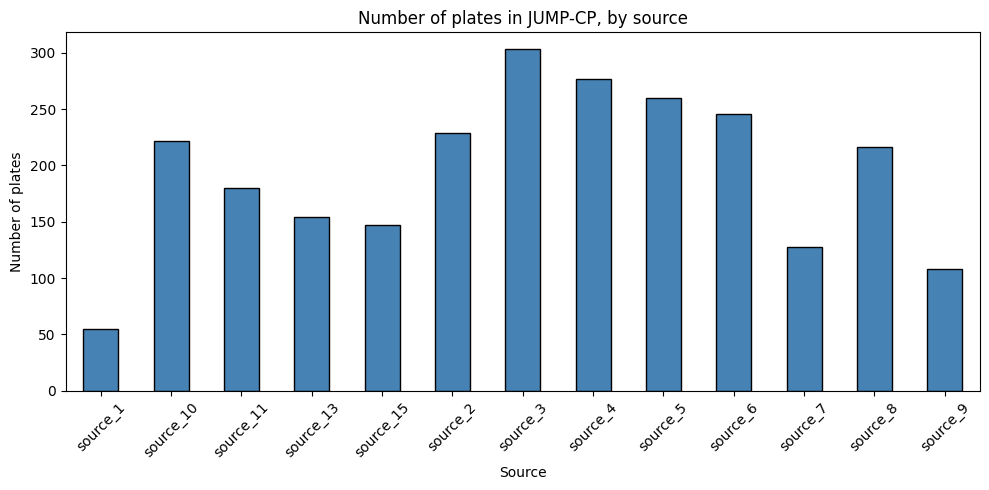

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
plates_per_source.plot(kind="bar", ax=ax, color="steelblue", edgecolor="black")
ax.set_title("Number of plates in JUMP-CP, by source")
ax.set_xlabel("Source")
ax.set_ylabel("Number of plates")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
compound_url = "https://github.com/jump-cellpainting/datasets/raw/main/metadata/compound.csv.gz"

compounds = pd.read_csv(compound_url)
print(f"Number of compounds: {len(compounds)}")
print(f"Columns: {list(compounds.columns)}")
compounds.head()

Number of compounds: 115796
Columns: ['Metadata_JCP2022', 'Metadata_InChIKey', 'Metadata_InChI', 'Metadata_SMILES']


,Metadata_JCP2022,Metadata_InChIKey,Metadata_InChI,Metadata_SMILES
0,JCP2022_000001,AAAHWCWPZPSPIW-UHFFFAOYSA-N,InChI=1S/C25H31N5O2/c1-4-23-26-14-16-30(23)24-...,CCc1nccn1-c1cccc(C2CCCN2C(=O)c2ccc(OCCN(C)C)cc...
1,JCP2022_000002,AAAJHRMBUHXWLD-UHFFFAOYSA-N,InChI=1S/C11H13ClN2O/c12-10-4-2-9(3-5-10)8-14-...,O=C1NCCCN1Cc1ccc(Cl)cc1
2,JCP2022_000004,AAANUZMCJQUYNX-UHFFFAOYSA-N,InChI=1S/C13H22N4O2S/c1-2-7-16-13(5-6-15-16)20...,CCCn1nccc1S(=O)(=O)N1CC2CCC1CNC2
3,JCP2022_000005,AAAQFGUYHFJNHI-UHFFFAOYSA-N,InChI=1S/C22H22ClN5O2/c1-4-24-20(29)12-18-22-2...,CCNC(=O)CC1N=C(c2ccc(Cl)cc2)c2cc(OC)ccc2-n2c(C...
4,JCP2022_000006,AAAROXVLYNJINN-UHFFFAOYSA-N,"InChI=1S/C16H20N6O/c1-16(2,3)22-13(10-5-6-10)7...",Cn1cc(-c2noc(-c3cc(C4CC4)n(C(C)(C)C)n3)n2)cn1


In [ ]:
well_url = "https://github.com/jump-cellpainting/datasets/raw/main/metadata/well.csv.gz"

wells = pd.read_csv(well_url)
print(f"Number of wells: {len(wells):,}")
print(f"Columns: {list(wells.columns)}")
wells.head()

Number of wells: 1,151,808
Columns: ['Metadata_Source', 'Metadata_Plate', 'Metadata_Well', 'Metadata_JCP2022']


,Metadata_Source,Metadata_Plate,Metadata_Well,Metadata_JCP2022
0,source_1,UL000081,A02,JCP2022_033924
1,source_1,UL000081,A03,JCP2022_085227
2,source_1,UL000081,A04,JCP2022_033924
3,source_1,UL000081,A05,JCP2022_047857
4,source_1,UL000081,A06,JCP2022_072229


## Summary of the JUMP-CP metadata exploration

### Scale of the dataset

- 2,525 plates across 13 sources (numbered source_1 to source_15, with source_12 and source_14 absent from the public release).
- 115,796 unique compounds, identified by an internal JUMP code (`Metadata_JCP2022`) and described by InChIKey, InChI, and SMILES : a full chemical catalog.
- 1,151,808 wells in total. With typically 4-9 imaging sites per well and 5 fluorescence channels per site, this scales to *tens of millions* of raw images ; which explains the ~85 TB raw size of JUMP-CP.

### Composition by plate type

| Plate type | Count | Proportion | What it is |
|---|---|---|---|
| COMPOUND | 1,876 | 74% | Compound perturbation plates ; the main drug-discovery target |
| ORF | 251 | 10% | Gene overexpression perturbations |
| CRISPR | 148 | 6% | Gene knockout perturbations |
| TARGET2 | 141 | 6% | Reference plates of 306 diverse compounds, repeated each batch for cross-source alignment |
| DMSO | 77 | 3% | Entire DMSO-only plates, used for calibration |
| COMPOUND_EMPTY, POSCON8, TARGET1 | 32 | <2% | Smaller categories |

### Strong technical variability across sources

Source counts are highly uneven:

- **source_3**: 303 plates
- **source_4**: 277 plates
- **source_5**: 260 plates
- **source_9**: 108 plates
- **source_7**: 128 plates
- **source_1**: 55 plates
- ...

That's roughly a 5.5× spread between the most and least productive sources. This is precisely the kind of variability Phenoseeker's normalization (well mean -> sphering on DMSO controls -> inverse normal transform) is designed to neutralize : any signal that correlates with source or batch identity rather than with biology is treated as a *batch effect* to remove.